Importing The Dependencies

In [159]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [160]:
# loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv('/creditcard.csv')

In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
# first 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Importing the Dependencies

In [163]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [164]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [165]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [166]:
# distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [167]:
# separating the data for analysis
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [168]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [169]:
# statistical measures of the data
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [170]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [171]:
# compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Under-Sampling

Build a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions --> 492

In [172]:
legit_sample = legit.sample(n=492)

Concatenating two DataFrames

In [173]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [174]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
141733,84474.0,-4.194122,3.642421,-1.632717,0.034605,-2.360626,-0.850490,-1.623784,1.836094,-0.235357,...,0.596458,-0.987392,0.444564,0.323210,0.176196,0.125896,0.229079,0.040819,44.99,0
214860,139847.0,-0.846233,1.699797,-1.400780,-1.331462,1.040524,-1.019515,1.253160,0.158487,-0.576015,...,0.285874,1.018357,-0.137678,0.768891,-0.184530,0.048051,0.487652,0.320664,7.69,0
169455,119713.0,-1.777901,-0.361217,-2.391227,-1.388836,0.281370,1.626917,-0.699406,-0.574854,-1.105525,...,1.816809,0.878424,-0.072320,-0.893009,-1.835394,-0.309567,0.394488,-0.090873,147.50,0
257140,158024.0,1.381300,-1.685564,-1.082020,-0.768957,-0.343957,1.063194,-0.569930,0.335112,1.557288,...,0.421475,0.816283,0.051600,-0.268750,-0.653431,0.743398,-0.044637,-0.008556,289.80,0
132443,79988.0,1.109687,0.112759,0.501016,1.333039,-0.259534,0.001591,-0.082829,0.160590,0.132378,...,-0.046222,0.033460,-0.039392,0.211382,0.580437,-0.339592,0.031753,0.005910,6.87,0


In [175]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [176]:
new_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


In [177]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95487.546748,0.012370,0.039514,0.021249,0.038359,0.019289,0.058907,0.067317,-0.022493,-0.043966,...,0.022363,-0.025459,0.010878,0.038079,-0.018243,-0.037802,-0.008299,-0.017509,-0.003357,91.710610
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Splitting the data into Features & Targets

In [178]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [179]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
141733   84474.0 -4.194122  3.642421 -1.632717  0.034605 -2.360626 -0.850490   
214860  139847.0 -0.846233  1.699797 -1.400780 -1.331462  1.040524 -1.019515   
169455  119713.0 -1.777901 -0.361217 -2.391227 -1.388836  0.281370  1.626917   
257140  158024.0  1.381300 -1.685564 -1.082020 -0.768957 -0.343957  1.063194   
132443   79988.0  1.109687  0.112759  0.501016  1.333039 -0.259534  0.001591   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [180]:
print(Y)

141733    0
214860    0
169455    0
257140    0
132443    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


In [181]:
# Improved Train-Test Split
# Keep the original dataset for realistic testing

from sklearn.model_selection import train_test_split

# Original dataset features and target
X_original = credit_card_data.drop(columns='Class', axis=1)
Y_original = credit_card_data['Class']

# Split the original dataset
X_train_original, X_test_original, Y_train_original, Y_test_original = train_test_split(
    X_original,
    Y_original,
    test_size=0.2,
    stratify=Y_original,
    random_state=42
)

print("Original Training Data:", X_train_original.shape)
print("Original Test Data:", X_test_original.shape)

print("\nTraining Class Distribution:")
print(Y_train_original.value_counts())

print("\nTest Class Distribution:")
print(Y_test_original.value_counts())

Original Training Data: (227845, 30)
Original Test Data: (56962, 30)

Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test Class Distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [182]:
# Balance only the training data

train_data = X_train_original.copy()
train_data['Class'] = Y_train_original.values

# Separate legitimate and fraudulent transactions
legitimate = train_data[train_data.Class == 0]
fraud = train_data[train_data.Class == 1]

# Take the same number of legitimate transactions as fraud transactions
legitimate_sample = legitimate.sample(
    n=len(fraud),
    random_state=42
)

# Create balanced training dataset
balanced_train_data = pd.concat([legitimate_sample, fraud])

# Shuffle the balanced training data
balanced_train_data = balanced_train_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate features and target
X_train_balanced = balanced_train_data.drop(columns='Class')
Y_train_balanced = balanced_train_data['Class']

print("Balanced Training Data:", X_train_balanced.shape)

print("\nTraining Class Distribution:")
print(Y_train_balanced.value_counts())

Balanced Training Data: (788, 30)

Training Class Distribution:
Class
1    394
0    394
Name: count, dtype: int64


In [183]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

# Calculate evaluation metrics
improved_accuracy = accuracy_score(Y_test_original, improved_prediction)
improved_precision = precision_score(Y_test_original, improved_prediction)
improved_recall = recall_score(Y_test_original, improved_prediction)
improved_f1 = f1_score(Y_test_original, improved_prediction)

# Precision-Recall AUC
pr_auc = average_precision_score(
    Y_test_original,
    improved_model.predict_proba(X_test_original)[:, 1]
)

print("Improved Logistic Regression Evaluation")
print("---------------------------------------")
print(f"Accuracy  : {improved_accuracy:.4f}")
print(f"Precision : {improved_precision:.4f}")
print(f"Recall    : {improved_recall:.4f}")
print(f"F1-Score  : {improved_f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test_original, improved_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test_original, improved_prediction))

Improved Logistic Regression Evaluation
---------------------------------------
Accuracy  : 0.9572
Precision : 0.0357
Recall    : 0.9184
F1-Score  : 0.0687
PR-AUC    : 0.6606

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962


Confusion Matrix:
[[54433  2431]
 [    8    90]]


In [184]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_original)

# Train Logistic Regression on scaled data
scaled_model = LogisticRegression(max_iter=1000)

scaled_model.fit(X_train_scaled, Y_train_balanced)

# Make predictions
scaled_prediction = scaled_model.predict(X_test_scaled)

print("Scaled Logistic Regression model trained successfully!")

Scaled Logistic Regression model trained successfully!


In [185]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

# Evaluate scaled model
scaled_accuracy = accuracy_score(Y_test_original, scaled_prediction)
scaled_precision = precision_score(Y_test_original, scaled_prediction)
scaled_recall = recall_score(Y_test_original, scaled_prediction)
scaled_f1 = f1_score(Y_test_original, scaled_prediction)

# Calculate PR-AUC
scaled_pr_auc = average_precision_score(
    Y_test_original,
    scaled_model.predict_proba(X_test_scaled)[:, 1]
)

print("Scaled Logistic Regression Evaluation")
print("-------------------------------------")
print(f"Accuracy  : {scaled_accuracy:.4f}")
print(f"Precision : {scaled_precision:.4f}")
print(f"Recall    : {scaled_recall:.4f}")
print(f"F1-Score  : {scaled_f1:.4f}")
print(f"PR-AUC    : {scaled_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test_original, scaled_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test_original, scaled_prediction))

Scaled Logistic Regression Evaluation
-------------------------------------
Accuracy  : 0.9708
Precision : 0.0516
Recall    : 0.9184
F1-Score  : 0.0977
PR-AUC    : 0.4578

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962


Confusion Matrix:
[[55209  1655]
 [    8    90]]


In [186]:
# Final Model Comparison

final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Improved Logistic Regression',
        'Scaled Logistic Regression'
    ],
    'Accuracy': [
        accuracy,
        rf_accuracy,
        improved_accuracy,
        scaled_accuracy
    ],
    'Precision': [
        precision,
        rf_precision,
        improved_precision,
        scaled_precision
    ],
    'Recall': [
        recall,
        rf_recall,
        improved_recall,
        scaled_recall
    ],
    'F1-Score': [
        f1,
        rf_f1,
        improved_f1,
        scaled_f1
    ],
    'PR-AUC': [
        average_precision_score(
            Y_test,
            model.predict_proba(X_test)[:, 1]
        ),
        average_precision_score(
            Y_test,
            rf_model.predict_proba(X_test)[:, 1]
        ),
        pr_auc,
        scaled_pr_auc
    ]
})

print("Final Model Comparison")
print("======================")
display(final_comparison.round(4))

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,PR-AUC
0,Logistic Regression,0.9391,0.9886,0.8878,0.9355,0.9823
1,Random Forest,0.9340,1.0000,0.8673,0.9290,0.9861
2,Improved Logistic Regression,0.9572,0.0357,0.9184,0.0687,0.6606
3,Scaled Logistic Regression,0.9708,0.0516,0.9184,0.0977,0.4578


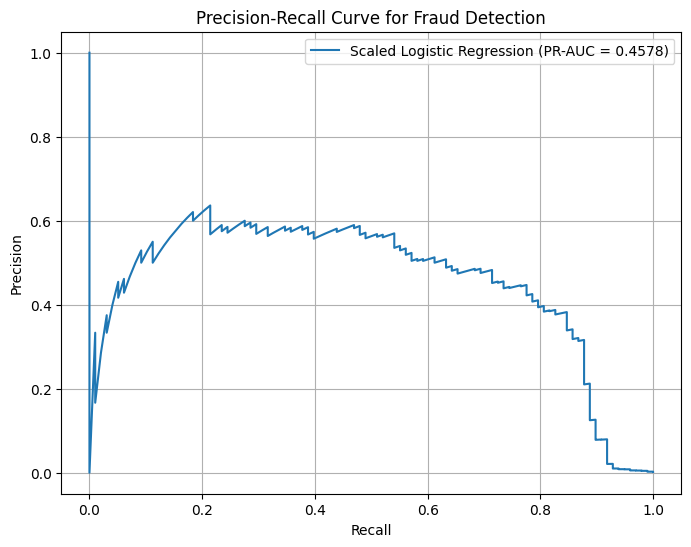

In [187]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get fraud probabilities from the scaled model
y_scores = scaled_model.predict_proba(X_test_scaled)[:, 1]

# Calculate Precision-Recall values
precision_values, recall_values, thresholds = precision_recall_curve(
    Y_test_original,
    y_scores
)

# Calculate PR-AUC
pr_auc_curve = average_precision_score(
    Y_test_original,
    y_scores
)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    label=f'Scaled Logistic Regression (PR-AUC = {pr_auc_curve:.4f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

In [188]:
# Fraud Risk Scoring System

def calculate_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"


# Select a transaction from the test dataset
sample_transaction = X_test_original.iloc[0:1]

# Get fraud probability
fraud_probability = scaled_model.predict_proba(
    scaler.transform(sample_transaction)
)[0][1]

# Calculate risk level
risk_level = calculate_risk(fraud_probability)

# Final prediction
prediction = scaled_model.predict(
    scaler.transform(sample_transaction)
)[0]

print("Credit Card Fraud Detection System")
print("==================================")
print(f"Fraud Probability : {fraud_probability:.2%}")
print(f"Risk Level        : {risk_level}")

if prediction == 1:
    print("Prediction        : FRAUDULENT TRANSACTION")
    print("Recommended Action: Review transaction")
else:
    print("Prediction        : LEGITIMATE TRANSACTION")
    print("Recommended Action: No immediate action required")

Credit Card Fraud Detection System
Fraud Probability : 2.14%
Risk Level        : Low Risk
Prediction        : LEGITIMATE TRANSACTION
Recommended Action: No immediate action required


In [189]:
# Model Explainability - Feature Importance

import pandas as pd
import numpy as np

# Get feature names
feature_names = X_train_balanced.columns

# Get model coefficients
coefficients = scaled_model.coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Importance': np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Absolute Importance',
    ascending=False
)

print("Top 10 Features Influencing Fraud Prediction")
print("=============================================")

display(feature_importance.head(10))

Top 10 Features Influencing Fraud Prediction


,Feature,Coefficient,Absolute Importance
14,V14,-3.102590,3.102590
4,V4,2.500608,2.500608
12,V12,-1.931635,1.931635
10,V10,-1.379344,1.379344
8,V8,-1.274826,1.274826
5,V5,1.003663,1.003663
16,V16,-0.774146,0.774146
3,V3,-0.773251,0.773251
20,V20,-0.699026,0.699026
29,Amount,0.532133,0.532133


In [190]:
# Train Logistic Regression on balanced training data

from sklearn.linear_model import LogisticRegression

improved_model = LogisticRegression(max_iter=1000)

# Train the model
improved_model.fit(X_train_balanced, Y_train_balanced)

# Predict on the untouched original test data
improved_prediction = improved_model.predict(X_test_original)

print("Improved Logistic Regression model trained successfully!")

Improved Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Split the data into Training data & Testing Data

In [191]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [192]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


In [193]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, Y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [194]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
X_test_prediction = model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(Y_test, X_test_prediction)
precision = precision_score(Y_test, X_test_prediction)
recall = recall_score(Y_test, X_test_prediction)
f1 = f1_score(Y_test, X_test_prediction)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test, X_test_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, X_test_prediction))

Model Evaluation
-----------------
Accuracy  : 0.9239
Precision : 0.9462
Recall    : 0.8980
F1-Score  : 0.9215

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        99
           1       0.95      0.90      0.92        98

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197


Confusion Matrix:
[[94  5]
 [10 88]]


In [195]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, Y_train)

# Make predictions
rf_prediction = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(Y_test, rf_prediction)
rf_precision = precision_score(Y_test, rf_prediction)
rf_recall = recall_score(Y_test, rf_prediction)
rf_f1 = f1_score(Y_test, rf_prediction)

print("Random Forest Evaluation")
print("------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test, rf_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, rf_prediction))

Random Forest Evaluation
------------------------
Accuracy  : 0.9086
Precision : 0.9444
Recall    : 0.8673
F1-Score  : 0.9043

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        99
           1       0.94      0.87      0.90        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197


Confusion Matrix:
[[94  5]
 [13 85]]


In [196]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'Precision': [precision, rf_precision],
    'Recall': [recall, rf_recall],
    'F1-Score': [f1, rf_f1]
})

print("Model Comparison")
print("----------------")
print(comparison.round(4))

Model Comparison
----------------
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.9239     0.9462  0.8980    0.9215
1        Random Forest    0.9086     0.9444  0.8673    0.9043


In [197]:
# Fraud Detection Demo

import numpy as np

# Select one transaction from the test dataset
sample_transaction = X_test.iloc[0:1]

# Make prediction
prediction = model.predict(sample_transaction)[0]

# Get fraud probability
probability = model.predict_proba(sample_transaction)[0][1]

print("Credit Card Fraud Detection")
print("---------------------------")

if prediction == 1:
    print("Prediction: FRAUDULENT TRANSACTION")
else:
    print("Prediction: LEGITIMATE TRANSACTION")

print(f"Fraud Probability: {probability:.2%}")

Credit Card Fraud Detection
---------------------------
Prediction: FRAUDULENT TRANSACTION
Fraud Probability: 100.00%


Model Evaluation

Accuracy Score

In [198]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [199]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.9555273189326556


In [200]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [201]:
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  0.9238578680203046


In [202]:
import pandas as pd

df = pd.read_csv('/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Graph for Dataset

In [203]:
import seaborn as sns
import pandas as pd

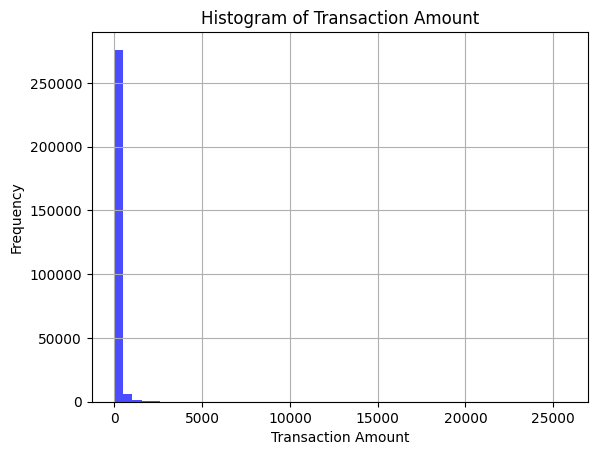

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Plot a histogram of the 'Amount' column
plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount')
plt.grid(True)
plt.show()


Correlation


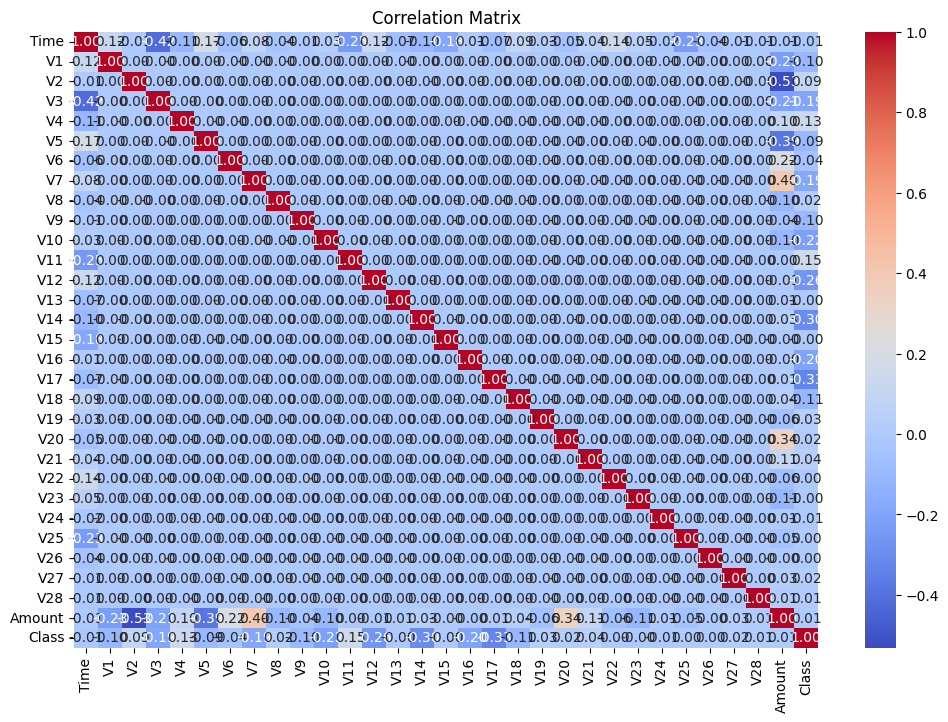

In [205]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Compute correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


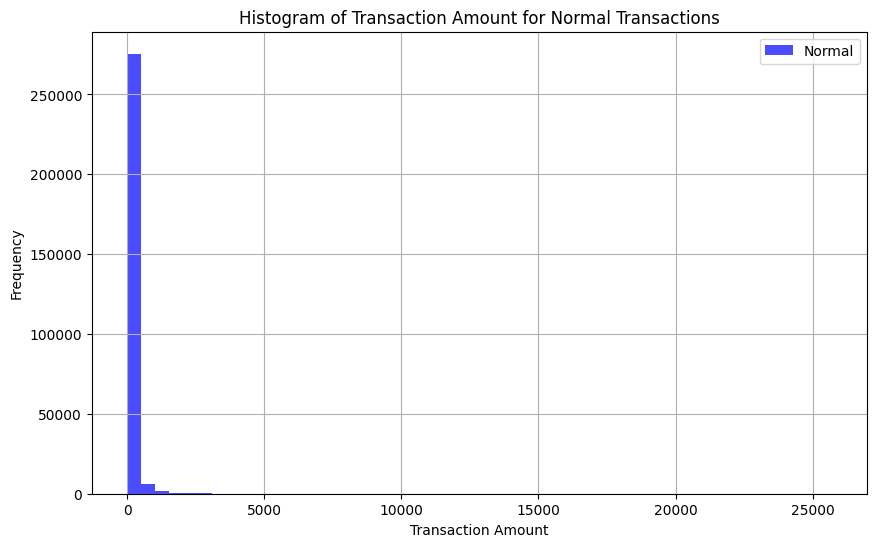

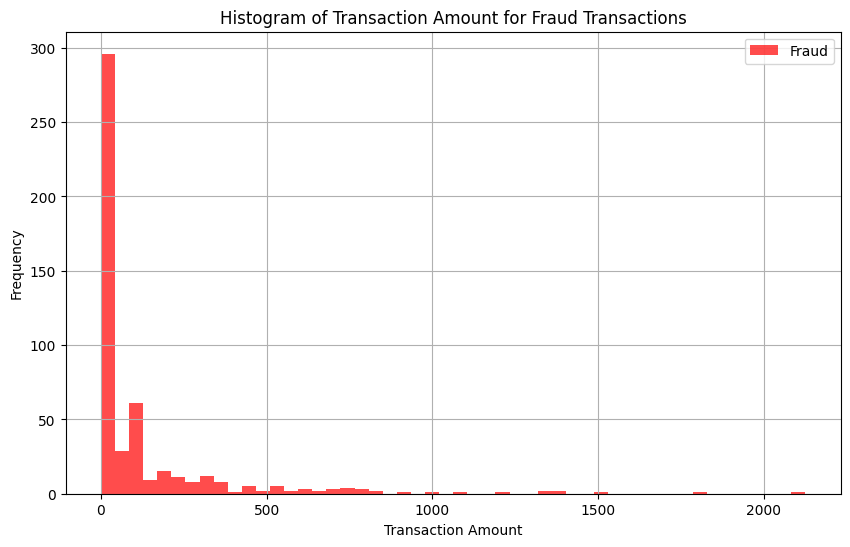

In [208]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot histogram for normal transactions
plt.figure(figsize=(10, 6))
plt.hist(normal_transactions['Amount'], bins=50, color='blue', alpha=0.7, label='Normal')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for fraud transactions
plt.figure(figsize=(10, 6))
plt.hist(fraud_transactions['Amount'], bins=50, color='red', alpha=0.7, label='Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()


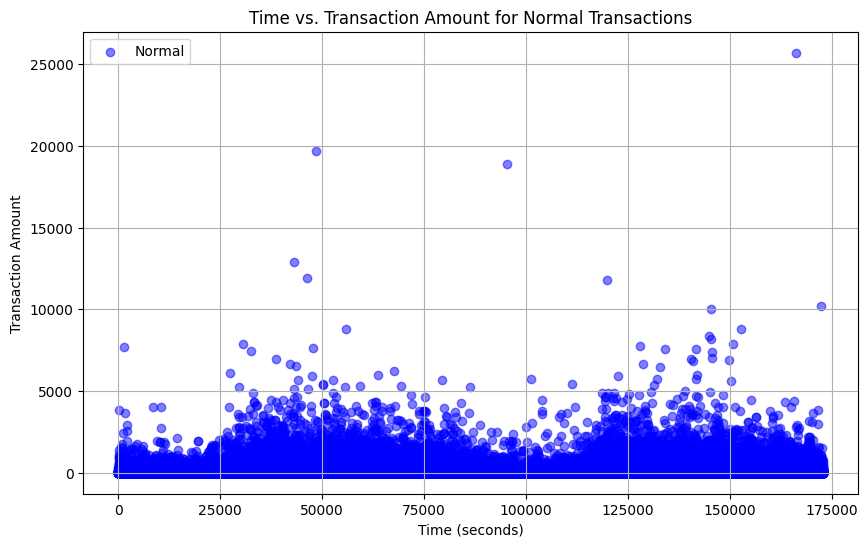

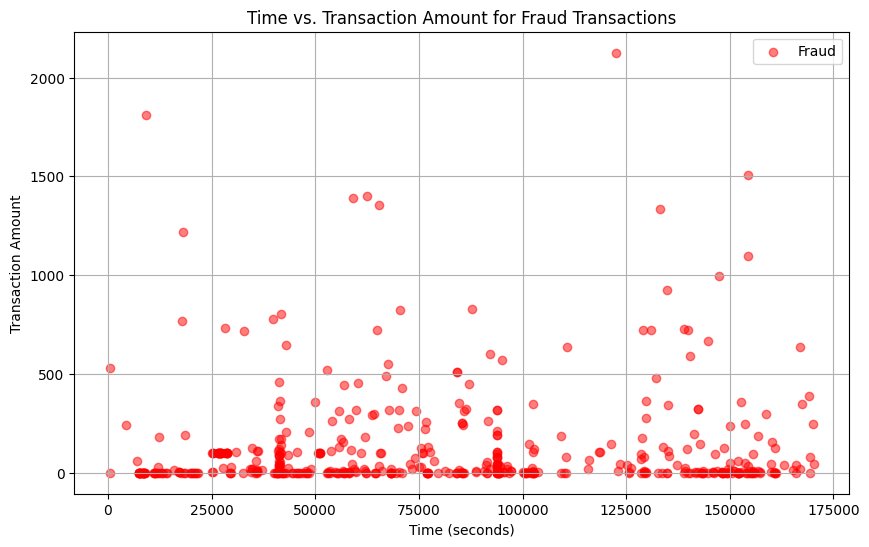

In [209]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot time vs. amount for normal transactions
plt.figure(figsize=(10, 6))
plt.scatter(normal_transactions['Time'], normal_transactions['Amount'], color='blue', alpha=0.5, label='Normal')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot time vs. amount for fraud transactions
plt.figure(figsize=(10, 6))
plt.scatter(fraud_transactions['Time'], fraud_transactions['Amount'], color='red', alpha=0.5, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

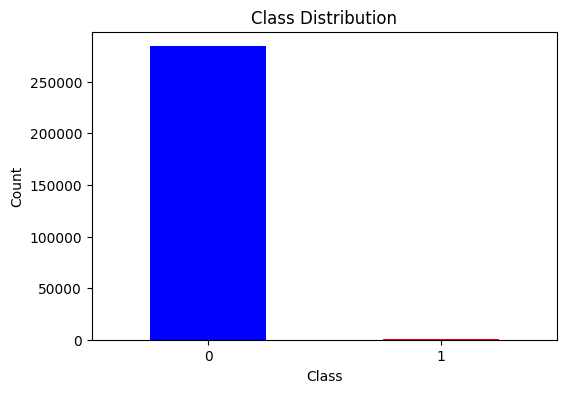

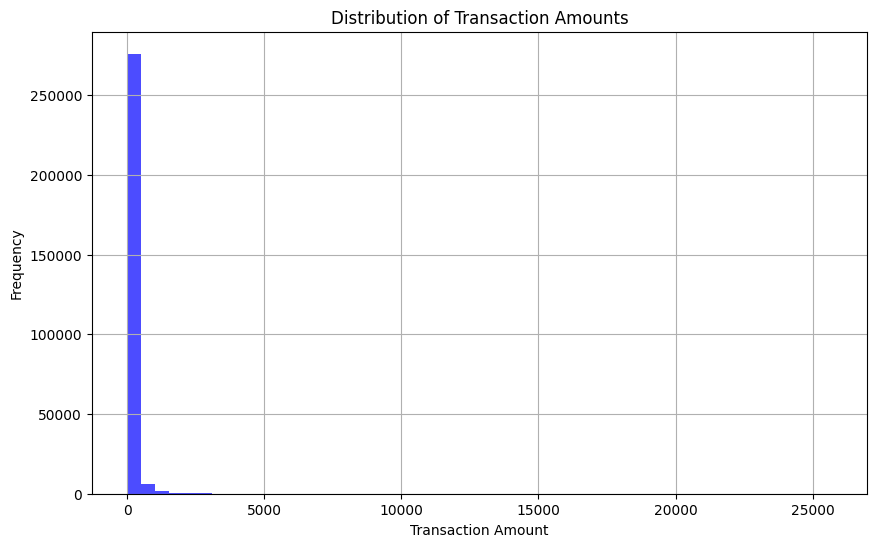

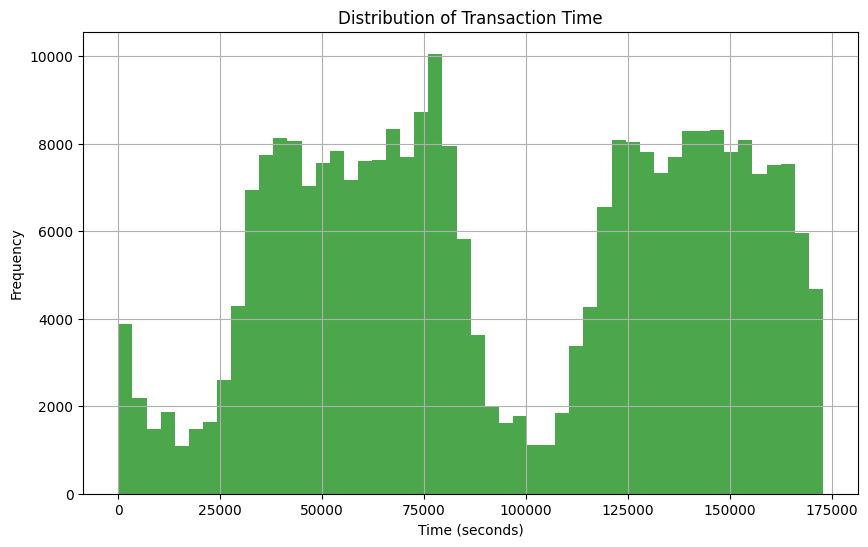


Correlation Matrix:
            Time            V1            V2            V3            V4  \
Time    1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1      0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2     -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3     -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4     -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   
V5      0.173072  1.812612e-17  5.157519e-16 -6.539009e-17 -1.719944e-15   
V6     -0.063016 -6.506567e-16  2.787346e-16  1.627627e-15 -7.491959e-16   
V7      0.084714 -1.005191e-15  2.055934e-16  4.895305e-16 -4.104503e-16   
V8     -0.036949 -2.433822e-16 -5.377041e-17 -1.268779e-15  5.697192e-16   
V9     -0.008660 -1.513678e-16  1.978488e-17  5.568367e-16  6.923247e-16   
V10     0.030617  7.388135e-17 -3.991394e-16  1.156587e-15  2.232685e-16   
V11    -0.247689  2.125498e-16  1.975426e-16  1.576830e-15  3.45938

In [210]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

# Summary statistics for numerical columns
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())

# Visualize class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Visualize the time distribution of transactions
plt.figure(figsize=(10, 6))
plt.hist(df['Time'], bins=50, color='green', alpha=0.7)
plt.title('Distribution of Transaction Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


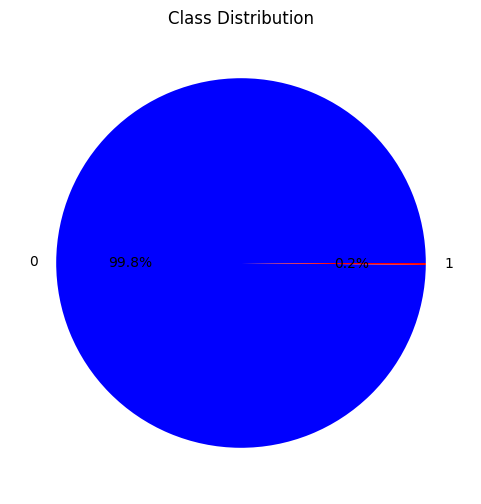

In [213]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Compute class distribution
class_distribution = df['Class'].value_counts()

# Plot a pie chart for class distribution
plt.figure(figsize=(6, 6))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Class Distribution')
plt.show()


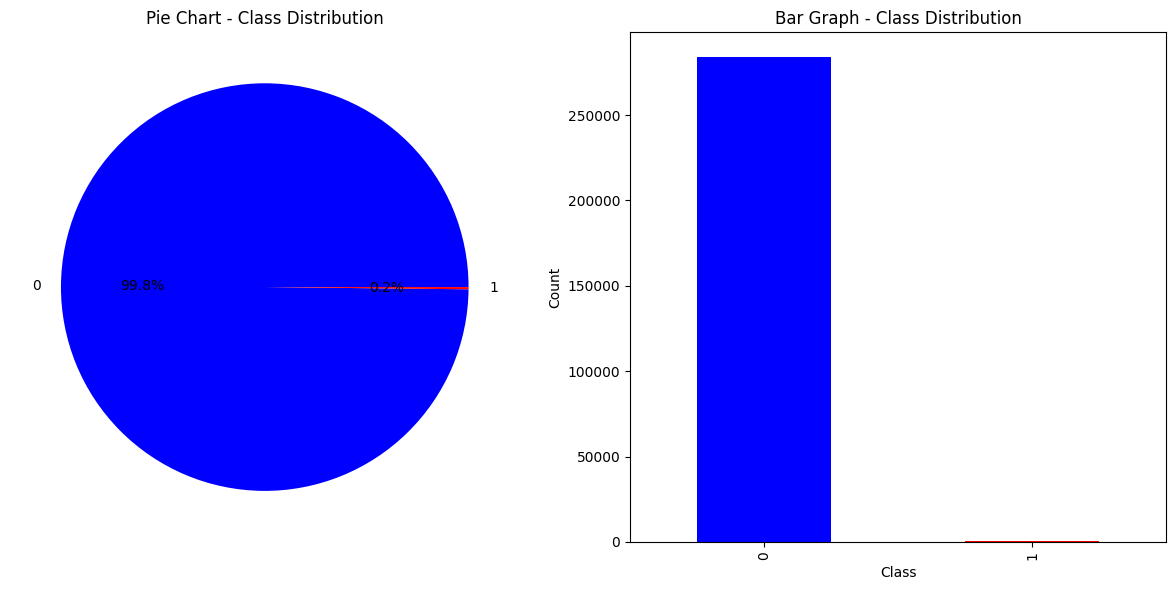

In [214]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Compute class distribution
class_distribution = df['Class'].value_counts()

# Plot pie chart for class distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Pie Chart - Class Distribution')

# Plot bar graph for class distribution
plt.subplot(1, 2, 2)
class_distribution.plot(kind='bar', color=['blue', 'red'])
plt.title('Bar Graph - Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [215]:
import sys

In [216]:
sys.path.append('/content')

In [217]:
!python test_class_distribution.py

python3: can't open file '/content/test_class_distribution.py': [Errno 2] No such file or directory


unittest

In [218]:
!pip install unittest
import unittest
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

class TestClassDistribution(unittest.TestCase):
    def setUp(self):
        # Load the dataset
        self.df = pd.read_csv('/creditcard.csv')

    def test_load_dataset(self):
        # Test if the dataset is loaded correctly
        self.assertIsNotNone(self.df, "Dataset is not loaded.")
        # You can add more assertions here to check the structure and content of the dataframe

    def test_plot_pie_chart(self):
        # Test if pie chart is plotted correctly
        class_distribution = self.df['Class'].value_counts()
        labels = class_distribution.index
        sizes = class_distribution.values
        colors = ['blue', 'red']

        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
        plt.title('Pie Chart - Class Distribution')

        # Check if the pie chart contains the correct number of wedges
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(labels))

        # Check if autopct is properly set
        percentages = [float(label.get_text().strip('%')) for label in plt.gcf().get_axes()[0].texts]
        self.assertTrue(all(np.isclose(percentages, class_distribution / sum(class_distribution) * 100)))

        # Close the plot to prevent displaying in the test environment
        plt.close()

    def test_plot_bar_graph(self):
        # Test if bar graph is plotted correctly
        class_distribution = self.df['Class'].value_counts()

        plt.figure(figsize=(6, 6))
        class_distribution.plot(kind='bar', color=['blue', 'red'])
        plt.title('Bar Graph - Class Distribution')
        plt.xlabel('Class')
        plt.ylabel('Count')

        # Check if the bar graph contains the correct number of bars
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(class_distribution))

ERROR: Could not find a version that satisfies the requirement unittest (from versions: none)
ERROR: No matching distribution found for unittest


In [219]:
unittest.main(exit=False)

E
ERROR: /root/ (unittest.loader._FailedTest./root/)
----------------------------------------------------------------------
AttributeError: module '__main__' has no attribute '/root/'

----------------------------------------------------------------------
Ran 1 test in 0.002s

FAILED (errors=1)


In [220]:
class TestClassDistribution(unittest.TestCase):
    def setUp(self):
        # Load the dataset
        self.df = pd.read_csv('/creditcard.csv')

    def test_load_dataset(self):
        # Test if the dataset is loaded correctly
        self.assertIsNotNone(self.df, "Dataset is not loaded.")
        # You can add more assertions here to check the structure and content of the dataframe

    def test_plot_pie_chart(self):
        # Test if pie chart is plotted correctly
        class_distribution = self.df['Class'].value_counts()
        labels = class_distribution.index
        sizes = class_distribution.values
        colors = ['blue', 'red']

        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
        plt.title('Pie Chart - Class Distribution')

        # Check if the pie chart contains the correct number of wedges
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(labels), "Incorrect number of wedges in the pie chart.")

        # Check if autopct is properly set

In [221]:
!pip install pandas matplotlib
import unittest
import pandas as pd
import matplotlib.pyplot as plt

class TestHistogramPlot(unittest.TestCase):
    def test_histogram_plot(self):
        # Load the dataset
        df = pd.read_csv('/creditcard.csv')

        # Plot a histogram of the 'Amount' column
        plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
        plt.xlabel('Transaction Amount')
        plt.ylabel('Frequency')
        plt.title('Histogram of Transaction Amount')
        plt.grid(True)
        # Save the plot to a file for manual inspection if needed
        plt.savefig('test_histogram.png')
        # Close the plot to prevent displaying in the test environment
        plt.close()

        # Assert that the dataframe is not empty
        self.assertFalse(df.empty, "DataFrame is empty.")
        # Add more assertions as needed to test the plot

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

...
----------------------------------------------------------------------
Ran 3 tests in 8.139s

OK


In [222]:
!pip install pytest

In [223]:
import pandas as pd
import matplotlib.pyplot as plt

# Fixture to load test data
@pytest.fixture
def test_data():
    return pd.read_csv('/creditcard.csv')

def test_data_loading(test_data):
    # Ensure dataset is loaded correctly
    assert not test_data.empty
    # Add more assertions to check dataset structure, columns, etc.

def test_data_processing(test_data):
    # Compute class distribution
    class_distribution = test_data['Class'].value_counts()
    # Ensure class distribution is computed accurately
    assert len(class_distribution) == 2  # Assuming binary classification
    # Add more assertions to check class distribution values, etc.

def test_visualization(test_data):
    # Compute class distribution
    class_distribution = test_data['Class'].value_counts()

    # Plot pie chart for class distribution
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
    plt.title('Pie Chart - Class Distribution')

    # Plot bar graph for class distribution
    plt.subplot(1, 2, 2)
    class_distribution.plot(kind='bar', color=['blue', 'red'])
    plt.title('Bar Graph - Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.close()  # Close the plot to avoid displaying during testing
    # Add assertions to check properties of the visualizations


In [224]:
!pip install pytest

In [225]:
import pytest

In [226]:
import time
import pandas as pd

def simulate_scalability_test(start_size, end_size, step):
    results = []
    for size in range(start_size, end_size + 1, step):
        start_time = time.time()
        df = pd.DataFrame({'Class': ['A' if i % 2 == 0 else 'B' for i in range(size)]})
        _ = df['Class'].value_counts()  # Simulate data processing
        end_time = time.time()
        processing_time = end_time - start_time
        results.append((size, processing_time))
        print(f"Dataset size: {size}, Processing time: {processing_time:.4f} seconds")
    return zip(*results)

if __name__ == '__main__':
    start_size, end_size, step = 100, 500, 100
    dataset_sizes, processing_times = simulate_scalability_test(start_size, end_size, step)


Dataset size: 100, Processing time: 0.0103 seconds
Dataset size: 200, Processing time: 0.0038 seconds
Dataset size: 300, Processing time: 0.0054 seconds
Dataset size: 400, Processing time: 0.0048 seconds
Dataset size: 500, Processing time: 0.0009 seconds


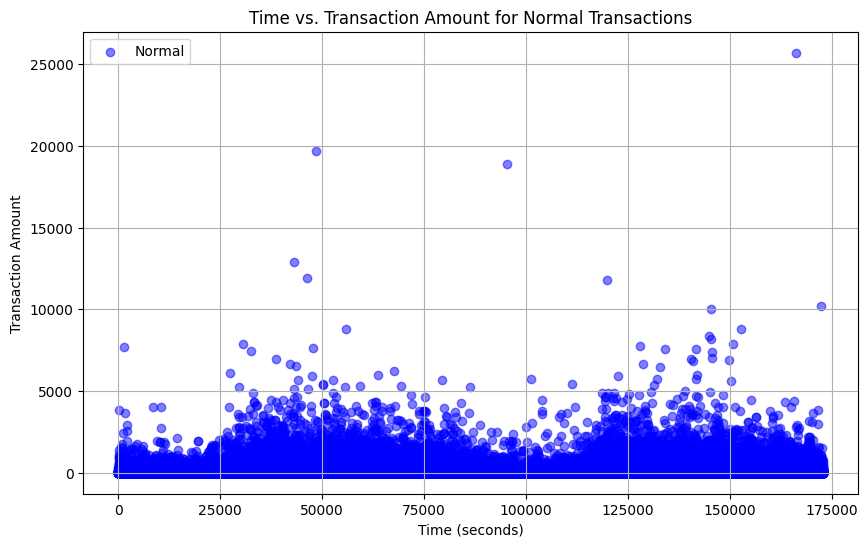

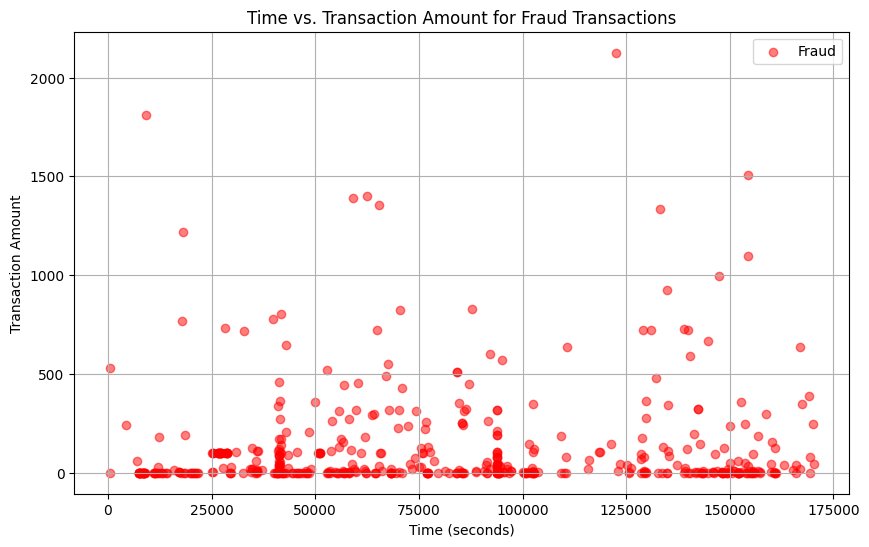

In [227]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot time vs. amount for normal transactions
plt.figure(figsize=(10, 6))
plt.scatter(normal_transactions['Time'], normal_transactions['Amount'], color='blue', alpha=0.5, label='Normal')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot time vs. amount for fraud transactions
plt.figure(figsize=(10, 6))
plt.scatter(fraud_transactions['Time'], fraud_transactions['Amount'], color='red', alpha=0.5, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()
